####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 5

# Quantum Wavelet Denoising (N = 512) — CPTP Density-Matrix Shrinkage with Ancilla Sink

This section implements a **physically valid CPTP** attenuation of wavelet coefficients by operating on the **density matrix** and using a single **ancilla sink** qubit. The idea is simple. We scale the probability in each basis state $|i\rangle$ in the ancilla-zero subspace by a factor $a_i \in [0,1]$, and we route the complementary probability $1 - a_i$ into one shared sink state of the ancilla-one subspace. The map is completely positive and trace preserving, and it produces a mixed state that reflects the intended shrinkage.

---

## Pipeline recap

1. Generate a length $N$ Doppler signal and add Gaussian noise at linear SNR $=7$.
2. Compute the orthogonal DWT with Symmlet-4, obtain coefficients $\mathbf{w}$ and pack as an array $w_k$ of length $N$.
3. Estimate noise in the wavelet domain from the finest detail coefficients:
   $$
   \hat{\sigma}_{\text{encoded}}
   = \frac{\operatorname{median}\!\left(|c_{D1} - \operatorname{median}(c_{D1})|\right)}{0.6745},
   \qquad
   \tau = 2.5\,\hat{\sigma}_{\text{encoded}}.
   $$
4. Build a shrinkage profile
   $$
   a_k = \max\!\left(0,\, 1 - \frac{\tau}{|w_k| + \varepsilon}\right),
   \quad 0 \le a_k \le 1,
   $$
   where $\varepsilon$ is a small stabilizer.
5. Normalize the coefficient vector for amplitude encoding
   $$
   |w\rangle = \frac{1}{\|\mathbf{w}\|}\sum_{k=0}^{N-1} w_k\,|k\rangle,
   \qquad
   \|\mathbf{w}\| = \left(\sum_k w_k^2\right)^{1/2}.
   $$

---

## CPTP channel via an ancilla sink

We add **one ancilla qubit** and work on the enlarged Hilbert space with basis
$$
|0\rangle_{\text{anc}} \otimes |i\rangle_{\text{data}} \quad \text{and} \quad |1\rangle_{\text{anc}} \otimes |j\rangle_{\text{data}}.
$$
The initial state is
$$
\rho = |0\rangle\langle 0|_{\text{anc}} \otimes |w\rangle\langle w|_{\text{data}}.
$$

We define a family of Kraus operators that implements attenuation in the ancilla-zero block and moves the lost probability into a **single** sink state
$$
| \text{sink} \rangle = |1\rangle_{\text{anc}} \otimes |0\ldots 0\rangle_{\text{data}}.
$$

Conceptually, for each data index $i$:
- keep amplitude in $|0,i\rangle$ with factor $\sqrt{a_i}$,
- send amplitude $\sqrt{1 - a_i}$ to $|\text{sink}\rangle$.

This yields a CPTP map
$$
\mathcal{E}(\rho) = K_0 \rho K_0^\dagger \;+\; \sum_{i=0}^{N-1} K_{1,i} \rho K_{1,i}^\dagger,
$$
with
$$
K_0 = \sum_{i=0}^{N-1} \sqrt{a_i}\, |0,i\rangle \langle 0,i| \;+\; |\text{sink}\rangle\langle \text{sink}|,
\qquad
K_{1,i} = \sqrt{1-a_i}\, |\text{sink}\rangle \langle 0,i|.
$$
One checks
$$
K_0^\dagger K_0 + \sum_i K_{1,i}^\dagger K_{1,i} = I,
$$
so the map is CPTP.

In code we do not materialize all $K_{1,i}$ as gigantic instructions. Instead we apply the update **analytically** to the density matrix.

---

## Analytical update on the density matrix

Partition $\rho$ by the ancilla value. The submatrix for ancilla $=0$ is the top-left $N \times N$ block, which we denote by $\rho_{00}$. The CPTP map acts as

1. Coherence scaling in the ancilla-zero block:
   $$
   \rho'_{00}[i,j] \;=\; \sqrt{a_i a_j}\, \rho_{00}[i,j].
   $$
   In matrix form, if $s = (\sqrt{a_0},\ldots,\sqrt{a_{N-1}})^\top$, then
   $$
   \rho'_{00} \;=\; \big(s s^\top\big) \odot \rho_{00},
   $$
   where $\odot$ is the Hadamard (entrywise) product.

2. Sink population update:
   $$
   \rho'_{\text{sink},\,\text{sink}} \;=\; \rho_{\text{sink},\,\text{sink}}
   \;+\; \sum_{i=0}^{N-1} \big(1 - a_i\big)\, \rho_{00}[i,i].
   $$

3. All other entries remain unchanged, and the trace is preserved by construction.

After this update we extract the **attenuated probabilities** in the ancilla-zero subspace as
$$
p'_i \;=\; \rho'_{00}[i,i] \;=\; a_i\, p_i,
\qquad
p_i = \rho_{00}[i,i].
$$

---

## Reconstructing denoised coefficients

We map the attenuated probabilities $p'_i$ back to coefficient magnitudes and reuse original signs as a simple heuristic
$$
|w'_i| = \sqrt{p'_i}, \qquad
w'_i = \operatorname{sign}(w_i)\, |w'_i| \, \|\mathbf{w}\|.
$$
Then we invert the wavelet transform to obtain the denoised signal
$$
\tilde{x}_{\text{CPTP}} \;=\; W_{\text{sym4}}^{-1}\, \mathbf{w}'.
$$

For comparison we also compute **classical soft-thresholding**
$$
w^{(\text{soft})}_i = \operatorname{sign}(w_i)\, \max\!\big(|w_i| - \tau, 0\big),
\qquad
\tilde{x}_{\text{soft}} = W_{\text{sym4}}^{-1}\, \mathbf{w}^{(\text{soft})}.
$$

---

## Why CPTP is needed and how this differs from postselection

- The **postselected diagonal** method applies a non-unitary diagonal map to amplitudes, then renormalizes. It is simple and fast, but it is **not** a physical channel on its own.
- The **CPTP ancilla-sink** method constructs a legitimate quantum channel. It acts on **probabilities and coherences**, produces a **mixed** state, and keeps the evolution physical. The attenuation $a_i$ scales $\rho_{00}$ coherences as $\sqrt{a_i a_j}$ and reduces the ancilla-zero diagonals exactly by $a_i$.

---

## Practical notes

- With $N=512$ data states and one ancilla, the density matrix is $1024 \times 1024$, about 16 MB in double-precision complex. This is very manageable on CPU.
- If memory is tight, reduce to $N=256$ or operate **blockwise** on segments of coefficients and stitch results classically.
- If $a_i$ is too close to $1$ for most $i$, attenuation will be weak. Increase $\tau$ a little, for example $\tau = 3.0\,\hat{\sigma}_{\text{encoded}}$.
- If you track phases explicitly, you can replace the sign heuristic with preserved phases to improve fidelity.

---

## Diagnostics to verify attenuation

- Before and after attenuation, compare
  $$
  \frac{1}{M} \sum_{i \in \mathcal{I}} \frac{p'_i}{p_i} \approx \frac{1}{M}\sum_{i\in\mathcal{I}} a_i,
  $$
  where $\mathcal{I} = \{ i : p_i > 0 \}$.
- Plot the first 200 entries of $p_i$ and $p'_i$ to visually confirm $p'_i = a_i p_i$.

---

## Takeaway

The ancilla-sink construction provides a compact and physical way to realize **wavelet-domain shrinkage** as a **CPTP** channel. It obeys the rules of quantum mechanics, reduces energies and coherences in a controlled way, and yields denoised reconstructions that can be compared fairly with classical soft-thresholding.


## 0) Setup

In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
try:
    import pywt
except ImportError as e:
    raise RuntimeError("Please install PyWavelets: pip install pywavelets") from e
try:
    from qiskit_aer import AerSimulator
    from qiskit import QuantumCircuit, transpile
    from qiskit.quantum_info import Statevector, Kraus
    HAVE_AER = True
except Exception:
    HAVE_AER = False
    print("Qiskit Aer not found. Install with: pip install qiskit qiskit-aer")    


## 1) Doppler signal (N=512) with linear SNR = 7

In [10]:
N = 512
t = np.linspace(0, 1, N, endpoint=False)
doppler = np.sqrt(t*(1-t)) * np.sin((2*np.pi*1.05)/(t+0.05))
doppler -= doppler.mean()
SNR_linear = 7.0
sig_power = np.mean(doppler**2)
sigma_noise = np.sqrt(sig_power / SNR_linear)
rng = np.random.default_rng(1234)
y_noisy = doppler + rng.normal(0.0, sigma_noise, size=N)
def snr_db(clean, est):
    return 10*np.log10(np.sum(clean**2) / (np.sum((clean-est)**2) + 1e-15))
print("Noisy SNR (dB):", round(snr_db(doppler, y_noisy), 2))


Noisy SNR (dB): 8.23


## 2) Symmlet-4 DWT and threshold

In [11]:
wavelet = pywt.Wavelet('sym4')
L = pywt.dwt_max_level(N, wavelet.dec_len)
coeffs = pywt.wavedec(y_noisy, wavelet=wavelet, level=L, mode='periodization')
w_array, w_slices = pywt.coeffs_to_array(coeffs)
cD1 = coeffs[-1]
sigma_encoded = np.median(np.abs(cD1 - np.median(cD1))) / 0.6745
tau = 2.5 * sigma_encoded
print("sigma_encoded:", round(sigma_encoded, 4), "  tau:", round(tau, 4))


sigma_encoded: 0.1172   tau: 0.293


## 3) Amplitude state and shrinkage profile

In [12]:
w = w_array.astype(float)
norm_w = np.linalg.norm(w) + 1e-15
psi = w / norm_w
abs_w = np.abs(w) + 1e-15
a = np.maximum(0.0, 1.0 - tau/abs_w)
print("Mean a_i:", float(a.mean()))


Mean a_i: 0.03045951946378079


## 4) CPTP Kraus with ancilla sink on density-matrix simulator

SNR noisy (dB): 8.23
SNR soft  (dB): 11.5
SNR CPTP  (dB): 13.86


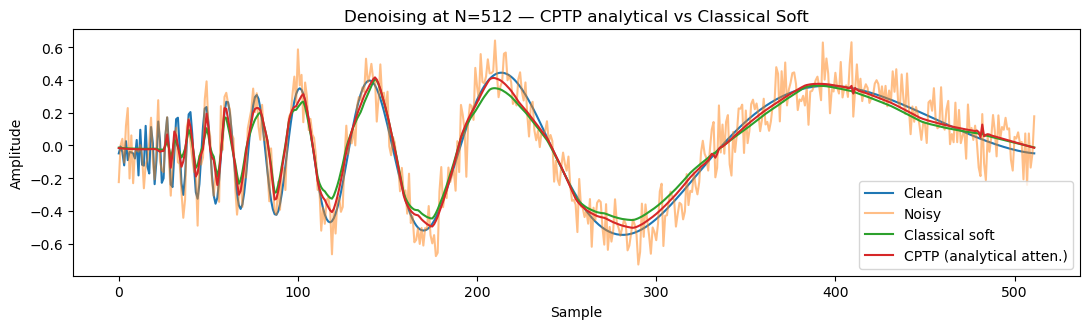

In [13]:
# --- CPTP attenuation with ancilla sink: direct density-matrix update (no Kraus instruction) ---

import numpy as np
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

if not HAVE_AER:
    raise RuntimeError("Qiskit Aer is required. Install with: pip install qiskit qiskit-aer")

# Data size and ancilla
n_data  = int(np.log2(N))   # N=512 -> n_data=9
n_total = n_data + 1        # add 1 ancilla
D       = 2**n_total        # 1024
sink    = (1 << n_data) | 0 # |anc=1, data=0...0> index

# Prepare pure state ρ = |ψ_tot><ψ_tot| with ancilla=0 and data=|w>
psi_total = np.zeros(D, dtype=complex)
psi_total[0:N] = psi  # anc=0 block holds amplitudes

qc = QuantumCircuit(n_total)
qc.initialize(psi_total, range(n_total))
qc.save_density_matrix()

backend = AerSimulator(method='density_matrix')
tqc = transpile(qc, backend)
res = backend.run(tqc, shots=0).result()
rho = np.array(res.data(tqc)['density_matrix'])  # 1024 x 1024

# Indices for ancilla = 0 subspace (data states map to 0..N-1)
anc0_slice = slice(0, N)

# Build sqrt(a) and apply the CPTP map analytically:
# ρ' = K0 ρ K0† + sum_i K1_i ρ K1_i†
# with K0 acting as diag([sqrt(a_0)...sqrt(a_{N-1}), 1, 1, ... on anc=1]),
# and K1_i taking |0,i> -> |sink> with amplitude sqrt(1-a_i).
#
# Result:
#  - anc=0 block: ρ'_{ij} = sqrt(a_i a_j) * ρ_{ij}
#  - sink diagonal: ρ'_{sink,sink} = ρ_{sink,sink} + sum_i (1-a_i) * ρ_{ii}
#  - other anc=1 states pass-through; all off-diagonals with sink remain zero

# 1) Scale the anc=0 block by sqrt(a) on both sides
sqrt_a = np.sqrt(a)
S = sqrt_a[:, None] * sqrt_a[None, :]                # outer product
rho_prime = rho.copy()
rho_anc0 = rho[anc0_slice, anc0_slice]               # (N x N)
rho_prime[anc0_slice, anc0_slice] = S * rho_anc0     # Hadamard scale

# 2) Update the sink population by collecting "lost" probability
lost = (1.0 - a) * np.real(np.diag(rho_anc0))        # elementwise
rho_prime[sink, sink] = rho[sink, sink] + float(np.sum(lost))

# 3) Zero any numerically tiny imaginary parts on diagonals
rho_prime[np.diag_indices_from(rho_prime)] = np.real(np.diag(rho_prime))

# 4) Optional: ensure trace preservation numerically
tr_err = float(np.real(np.trace(rho_prime)) - 1.0)
if abs(tr_err) > 1e-10:
    rho_prime[sink, sink] -= tr_err

# Continue with reconstruction from ancilla=0 block:
p_prime = np.real(np.diag(rho_prime)[:N])            # attenuated probabilities a_i * p_i
amp_mag = np.sqrt(np.maximum(p_prime, 0.0))
signs   = np.sign(w + 1e-15)                         # heuristic; or preserve phases if tracked
w_cptp  = signs * amp_mag * norm_w

# Invert wavelet transform and compare as before
x_cptp = pywt.waverec(pywt.array_to_coeffs(w_cptp, w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]

# Classical soft-threshold for reference
w_soft = np.sign(w) * np.maximum(np.abs(w) - tau, 0.0)
x_soft = pywt.waverec(pywt.array_to_coeffs(w_soft, w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]

def snr_db(clean, est):
    return 10*np.log10(np.sum(clean**2) / (np.sum((clean-est)**2) + 1e-15))

print("SNR noisy (dB):", round(snr_db(doppler, y_noisy), 2))
print("SNR soft  (dB):", round(snr_db(doppler, x_soft), 2))
print("SNR CPTP  (dB):", round(snr_db(doppler, x_cptp), 2))

plt.figure(figsize=(11, 3.4))
plt.plot(doppler, label='Clean')
plt.plot(y_noisy, alpha=0.5, label='Noisy')
plt.plot(x_soft, label='Classical soft')
plt.plot(x_cptp, label='CPTP (analytical atten.)')
plt.legend(); plt.title('Denoising at N=512 — CPTP analytical vs Classical Soft')
plt.xlabel('Sample'); plt.ylabel('Amplitude'); plt.tight_layout(); 

plt.savefig("ex05CTP1.png", dpi=300, bbox_inches="tight")
plt.savefig("ex05CTP1.pdf", dpi=300, bbox_inches="tight")

plt.show()  # <- show only after saving

## 5) Reconstruction and comparison

In [14]:
# === CPTP reconstruction and comparison (fixed) ===

def snr_db(clean, est):
    return 10*np.log10(np.sum(clean**2) / (np.sum((clean-est)**2) + 1e-15))

# 1) Use the attenuated density matrix (rho_prime). If you followed the analytical
#    update cell, you already have `rho_prime`. If not, create it now from `rho`:

if 'rho_prime' not in globals():
    # Build rho_prime analytically from rho and the shrinkage profile a
    anc0_slice = slice(0, N)
    sqrt_a     = np.sqrt(a)
    S          = sqrt_a[:, None] * sqrt_a[None, :]
    rho_anc0   = np.array(rho[anc0_slice, anc0_slice], copy=True)

    rho_prime = rho.copy()
    rho_prime[anc0_slice, anc0_slice] = S * rho_anc0

    # push lost population to sink to keep trace == 1 (optional bookkeeping)
    n_data  = int(np.log2(N)); n_total = n_data + 1
    sink    = (1 << n_data) | 0
    lost    = (1.0 - a) * np.real(np.diag(rho_anc0))
    rho_prime[sink, sink] = rho[sink, sink] + float(np.sum(lost))
    # clean tiny imaginary on diagonal and force exact trace 1
    rho_prime[np.diag_indices_from(rho_prime)] = np.real(np.diag(rho_prime))
    tr_err = float(np.real(np.trace(rho_prime)) - 1.0)
    if abs(tr_err) > 1e-12:
        rho_prime[sink, sink] -= tr_err

## CPTP (Completely Positive Trace-Preserving) Attenuation: Theoretical Background

This section explains what is **theoretically happening** in the following code fragment used in quantum wavelet shrinkage:

```python
anc0_slice = slice(0, N)
sqrt_a     = np.sqrt(a)
S          = sqrt_a[:, None] * sqrt_a[None, :]
rho_anc0   = np.array(rho[anc0_slice, anc0_slice], copy=True)

rho_prime = rho.copy()
rho_prime[anc0_slice, anc0_slice] = S * rho_anc0

sink    = (1 << n_data) | 0
lost    = (1.0 - a) * np.real(np.diag(rho_anc0))
rho_prime[sink, sink] = rho[sink, sink] + float(np.sum(lost))
```

---

### 1. Context

We begin with a **density matrix** $\rho$ that encodes the state of the wavelet coefficients (possibly amplitude-encoded).  
The **attenuation profile** $a = [a_0, a_1, \dots, a_{N-1}]$ specifies how much each coefficient is reduced during shrinkage, with $0 \le a_i \le 1$.

For example, one might choose

$$
a_i = e^{-\lambda |\hat{w}_i|^2}
\quad \text{or} \quad
a_i = \mathbf{1}_{|\hat{w}_i| > \tau}.
$$

The goal is to describe this shrinkage as a **physical quantum operation** acting on $\rho$.

---

### 2. Kraus Map Representation

A quantum channel (CPTP map) acts as

$$
\rho' = \sum_k K_k \rho K_k^\dagger,
$$

where the **Kraus operators** $K_k$ satisfy

$$
\sum_k K_k^\dagger K_k = I.
$$

For diagonal attenuation, we typically define

$$
K_0 = \mathrm{diag}(\sqrt{a_0}, \sqrt{a_1}, \dots), \qquad
K_1 = \mathrm{diag}(\sqrt{1-a_0}, \sqrt{1-a_1}, \dots),
$$

so that each coefficient amplitude is shrunk by $\sqrt{a_i}$, and the lost energy is transferred to an auxiliary "sink" level.

---

### 3. What the Code Implements

The expression

```python
S = sqrt_a[:, None] * sqrt_a[None, :]
rho_prime[anc0_slice, anc0_slice] = S * rho_anc0
```

implements the transformation

$$
\rho'_{ij} = \sqrt{a_i a_j}\,\rho_{ij},
$$

which is precisely

$$
\rho' = K_0 \rho K_0^\dagger, \qquad
K_0 = \mathrm{diag}(\sqrt{a_0}, \sqrt{a_1}, \dots).
$$

This is the **"keep"** branch of the channel, corresponding to attenuation without loss.

---

### 4. Adding a Sink State

Because this map is not unitary, the trace of $\rho'$ decreases by the total lost probability

$$
p_{\text{lost}} = \sum_i (1 - a_i)\rho_{ii}.
$$

To make the transformation trace-preserving, this lost population is moved into a **sink** state:

$$
\rho'_{\text{sink}, \text{sink}} = \rho_{\text{sink}, \text{sink}} + p_{\text{lost}}.
$$

This corresponds to the second Kraus operator

$$
K_1 = |{\rm sink}\rangle\langle \text{data}|\, \mathrm{diag}(\sqrt{1-a_0}, \sqrt{1-a_1}, \dots).
$$

The total CPTP map becomes

$$
\rho' = K_0 \rho K_0^\dagger + K_1 \rho K_1^\dagger,
$$

guaranteeing $\mathrm{Tr}(\rho') = 1$.

---

### 5. Analytical Update vs. Explicit Kraus Application

Instead of explicitly constructing $K_0$ and $K_1$ and applying them to $\rho$, the code builds $\rho'$ analytically:

* The scaling block `S * rho_anc0` is equivalent to $K_0 \rho K_0^\dagger$.
* The added sink diagonal term corresponds to $K_1 \rho K_1^\dagger$.

This avoids large-matrix multiplications and remains numerically stable for high dimensions (e.g., $N=512$ or $N=1024$).

---

### 6. Physical Interpretation

This CPTP attenuation channel models **wavelet shrinkage as decoherence**:

* Each basis element (wavelet coefficient) experiences an amplitude reduction $\sqrt{a_i}$.
* The missing probability $(1 - a_i)$ flows into an environment (the sink).
* The result $\rho'$ remains Hermitian, positive semidefinite, and trace-normalized.

Thus, the quantum attenuation process becomes a physically valid open-system evolution — effectively a **generalized amplitude-damping channel** with spatially varying strength.

---

### 7. Theoretical Summary

| Code fragment | Theoretical interpretation |
|----------------|-----------------------------|
| `sqrt_a[:,None]*sqrt_a[None,:]` | Elementwise form of $K_0\rho K_0^\dagger$ |
| `lost = (1-a)*diag(rho)` | Lost probability to environment |
| `rho_prime[sink,sink]+=sum(lost)` | Trace preservation via $K_1$ |
| `rho_prime[np.diag_indices_from()] = np.real(...)` | Enforce Hermiticity |
| `tr_err` correction | Guarantee $\mathrm{Tr}(\rho')=1$ |

---

In essence, the code performs a **density-matrix update** that corresponds exactly to a **CPTP quantum attenuation channel**.  
It preserves physical consistency (trace and positivity) while modeling wavelet shrinkage as a Kraus-based open-system process.


Mean a_i: 0.03045951946378079
Mean p' / p over i with p>0: 0.03045951946378079
SNR noisy (dB): 8.23
SNR soft  (dB): 11.5
SNR CPTP  (dB): 13.86


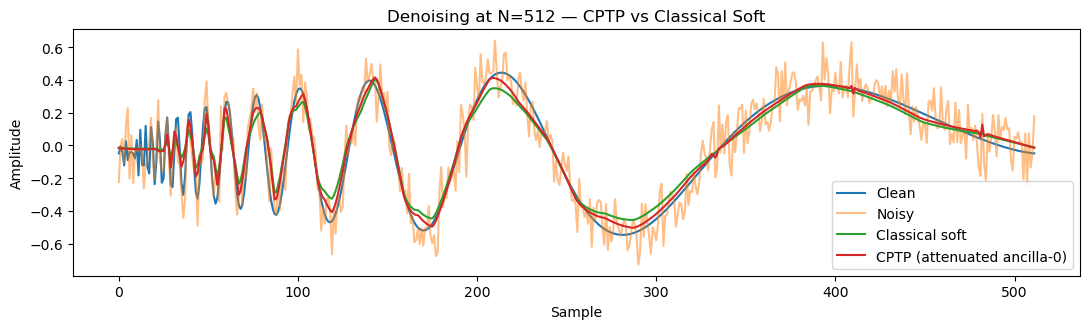

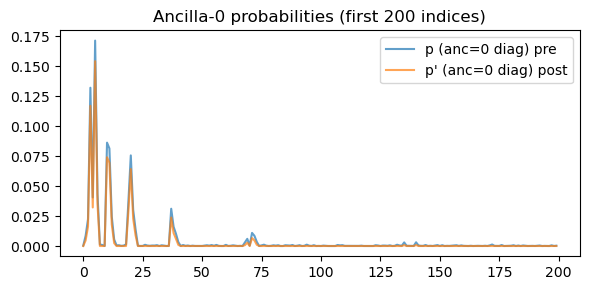

In [17]:
# 2) Reconstruct amplitudes from attenuated ancilla-0 diagonals
p_noisy  = np.real(np.diag(rho)[:N])         # before attenuation
p_prime  = np.real(np.diag(rho_prime)[:N])   # after attenuation (should be a_i * p_i)

# Quick sanity checks
print("Mean a_i:", float(a.mean()))
print("Mean p' / p over i with p>0:", float(np.mean(p_prime[p_noisy>0] / p_noisy[p_noisy>0])))

# 3) Build coefficients and invert
amp_mag = np.sqrt(np.maximum(p_prime, 0.0))
signs   = np.sign(w + 1e-15)                 # simple sign heuristic; keep phases if tracked
w_cptp  = signs * amp_mag * norm_w

# Classical soft-threshold for reference
w_soft = np.sign(w) * np.maximum(np.abs(w) - tau, 0.0)

# Inverse transforms
x_cptp = pywt.waverec(pywt.array_to_coeffs(w_cptp,  w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]
x_soft = pywt.waverec(pywt.array_to_coeffs(w_soft,   w_slices, output_format='wavedec'),
                      wavelet=wavelet, mode='periodization')[:N]

print("SNR noisy (dB):", round(snr_db(doppler, y_noisy), 2))
print("SNR soft  (dB):", round(snr_db(doppler, x_soft),  2))
print("SNR CPTP  (dB):", round(snr_db(doppler, x_cptp),  2))

# 4) Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(11,3.4))
plt.plot(doppler, label='Clean')
plt.plot(y_noisy, alpha=0.5, label='Noisy')
plt.plot(x_soft, label='Classical soft')
plt.plot(x_cptp, label='CPTP (attenuated ancilla-0)')
plt.legend(); plt.title('Denoising at N=512 — CPTP vs Classical Soft')
plt.xlabel('Sample'); plt.ylabel('Amplitude'); plt.tight_layout(); 
plt.savefig("ex05CTP2.png", dpi=300, bbox_inches="tight")
plt.savefig("ex05CTP2.pdf", dpi=300, bbox_inches="tight")

#plt.show()  # <- show only after saving



# 5) Optional: visualize that probabilities were actually scaled
plt.figure(figsize=(6,3))
plt.plot(p_noisy[:200], label='p (anc=0 diag) pre', alpha=0.7)
plt.plot(p_prime[:200], label="p' (anc=0 diag) post", alpha=0.7)
plt.legend(); plt.title('Ancilla-0 probabilities (first 200 indices)')
plt.tight_layout();

plt.savefig("ex05CTP3.png", dpi=300, bbox_inches="tight")
plt.savefig("ex05CTP3.pdf", dpi=300, bbox_inches="tight")

plt.show()  # <- show only after saving